แสดงชื่อ ขนาดและจำนวนไฟล์  ".txt "ทั้งหมดในทุกโฟลเดอร์ย่อยของโฟลเดอร์  N พร้อมแสดงโฟเดอร์ย่อยที่จัดเก็บไฟล์

In [1]:
import os

def scan_txt_files(folder_path):
    for root, _, files in os.walk(folder_path):
        for file_name in files:
            if file_name.endswith(".txt"):
                file_path = os.path.join(root, file_name)
                print("-" * 50)
                # เปิดไฟล์ .txt เพื่ออ่านข้อมูล
                with open(file_path, "r", encoding="utf-8") as file:
                    lines = file.readlines()
                    
                    # แสดงข้อมูลที่คุณต้องการ
                    num_rows = len(lines)
                    num_columns = len(lines[0].split()) if num_rows > 0 else 0
                    header = lines[0].strip() if num_rows > 0 else None
                    
                    print(f"ไฟล์: {file_name}")
                    if header:
                        print(f"หัวเรื่อง: {header}")
                    print(f"จำนวนแถว: {num_rows}")
                    print(f"จำนวนคอลัมน์: {num_columns}")
                    print(f"ที่อยู่ของไฟล์: {file_path}")  # เพิ่มแถวนี้เพื่อแสดงที่อยู่ของไฟล์
                    print("\n")

# ระบุโฟลเดอร์หลักที่คุณต้องการสแกน
main_folder = "N"
scan_txt_files(main_folder)


--------------------------------------------------
ไฟล์: N8_W.txt
หัวเรื่อง: N_8_WaterPure water tube 5ml   No reagent :08/10/2023,17:27:32
จำนวนแถว: 681
จำนวนคอลัมน์: 7
ที่อยู่ของไฟล์: N/N8_W.txt


--------------------------------------------------
ไฟล์: N10_W.txt
หัวเรื่อง: N_10_WaterPure water tube 5ml   No reagent :08/10/2023,18:06:52
จำนวนแถว: 681
จำนวนคอลัมน์: 7
ที่อยู่ของไฟล์: N/N10_W.txt


--------------------------------------------------
ไฟล์: N80_NoR.txt
หัวเรื่อง: N_80_No_RNH4CL 80mg/L tube  5ml  No Reagent :08/10/2023,21:54:35
จำนวนแถว: 681
จำนวนคอลัมน์: 7
ที่อยู่ของไฟล์: N/N80_NoR.txt


--------------------------------------------------
ไฟล์: N20_NoR.txt
หัวเรื่อง: N_20_No_RNH4CL 20mg/L tube  5ml  No Reagent :08/10/2023,19:58:22
จำนวนแถว: 681
จำนวนคอลัมน์: 7
ที่อยู่ของไฟล์: N/N20_NoR.txt


--------------------------------------------------
ไฟล์: N4_NoR.txt
หัวเรื่อง: N_4_No_RNH4CL 4mg/L tube  5ml  No Reagent :08/10/2023,16:26:19
จำนวนแถว: 681
จำนวนคอลัมน์: 7
ที่อยู่ของไฟล

แปลงไฟล์ txt ในแต่ละโฟลเดอร์  เป็น cvs   และบันทึกไว้ในโฟลเดอร์  NdatasetCSV 

In [2]:
import os
import csv

# ระบุโฟลเดอร์หลัก N_raw
main_folder = "N"

# ระบุโฟลเดอร์ที่จะบันทึกไฟล์ .csv
output_folder_path = "NdatasetCSV"

# ตรวจสอบว่าโฟลเดอร์ output_folder_path มีอยู่หรือไม่ และสร้างถ้าไม่มี
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

# วนลูปผ่านโฟลเดอร์และไฟล์ทั้งหมดในโฟลเดอร์หลัก
for root, _, files in os.walk(main_folder):
    for filename in files:
        if filename.endswith(".txt"):
            # รับที่อยู่ของไฟล์ .txt
            input_file_path = os.path.join(root, filename)
            
            # สร้างชื่อไฟล์ .csv ใหม่โดยนำชื่อไฟล์เดิมมาใช้
            output_file_path = os.path.join(output_folder_path, os.path.splitext(filename)[0] + ".csv")

            # เปิดไฟล์ .txt สำหรับอ่าน
            with open(input_file_path, "r") as txt_file:
                # อ่านข้อมูลทั้งหมดจากไฟล์ .txt
                lines = txt_file.readlines()

            # ตรวจสอบว่ามีข้อมูลในไฟล์หรือไม่
            if len(lines) > 0:
                # ลบข้อมูลในแถวแรก
                lines = lines[1:]

                # เปิดไฟล์ .csv สำหรับเขียน
                with open(output_file_path, "w", newline='') as csv_file:
                    # สร้างอ็อบเจ็กต์ writer สำหรับเขียนข้อมูล CSV
                    csv_writer = csv.writer(csv_file)

                    # เขียนข้อมูลลงในไฟล์ .csv
                    for line in lines:
                        # แบ่งข้อมูลในแต่ละบรรทัดด้วยเครื่องหมาย "," และลบช่องว่างด้านหน้าและหลัง
                        row_data = line.strip().split(",")
                        csv_writer.writerow(row_data)

            print(f"แปลงไฟล์ '{filename}' และบันทึกเป็น '{os.path.basename(output_file_path)}'")

print("เสร็จสิ้นการแปลงไฟล์ .txt เป็น .csv และบันทึกในโฟลเดอร์ NdatasetCSV")


แปลงไฟล์ 'N8_W.txt' และบันทึกเป็น 'N8_W.csv'
แปลงไฟล์ 'N10_W.txt' และบันทึกเป็น 'N10_W.csv'
แปลงไฟล์ 'N80_NoR.txt' และบันทึกเป็น 'N80_NoR.csv'
แปลงไฟล์ 'N20_NoR.txt' และบันทึกเป็น 'N20_NoR.csv'
แปลงไฟล์ 'N4_NoR.txt' และบันทึกเป็น 'N4_NoR.csv'
แปลงไฟล์ 'N40_NoR.txt' และบันทึกเป็น 'N40_NoR.csv'
แปลงไฟล์ 'N6_NoR.txt' และบันทึกเป็น 'N6_NoR.csv'
แปลงไฟล์ 'N100_NoR.txt' และบันทึกเป็น 'N100_NoR.csv'
แปลงไฟล์ 'N100_W.txt' และบันทึกเป็น 'N100_W.csv'
แปลงไฟล์ 'N10_NoR.txt' และบันทึกเป็น 'N10_NoR.csv'
แปลงไฟล์ 'N2_NoR.txt' และบันทึกเป็น 'N2_NoR.csv'
แปลงไฟล์ 'N20_W.txt' และบันทึกเป็น 'N20_W.csv'
แปลงไฟล์ 'N2_W.txt' และบันทึกเป็น 'N2_W.csv'
แปลงไฟล์ 'N60_W.txt' และบันทึกเป็น 'N60_W.csv'
แปลงไฟล์ 'N8_NoR.txt' และบันทึกเป็น 'N8_NoR.csv'
แปลงไฟล์ 'N60_NoR.txt' และบันทึกเป็น 'N60_NoR.csv'
แปลงไฟล์ 'N40_W.txt' และบันทึกเป็น 'N40_W.csv'
แปลงไฟล์ 'N80_W.txt' และบันทึกเป็น 'N80_W.csv'
แปลงไฟล์ 'N6_W.txt' และบันทึกเป็น 'N6_W.csv'
แปลงไฟล์ 'N4_W.txt' และบันทึกเป็น 'N4_W.csv'
เสร็จสิ้นการแปลงไฟล์ .txt เป็น .

เลื่อนข้อมูลในคอลัมน์ 'Intensity' ขึ้นหนึ่งแถว และลบแถวที่มีคอลัมน์ 'Order' เท่ากับ 0 และคอลัมน์ 'Color' เท่ากับ 'Black' หลังจากนั้นบันทึกข้อมูลที่แก้ไขแล้วในไฟล์ .csv 

In [3]:
import os
import pandas as pd

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file with the specified column names
    df = pd.read_csv(file_path, names=column_names)

    # Shift the data in the 'Intensity' column up by one row
    df['Intensity'] = df['Intensity'].shift(-1)

    # Drop rows where 'Order' is equal to 0 and 'Color' is equal to 'Black'
    df = df[(df['Order'] != 0) | (df['Color'] != 'Black')]

    # Specify the original file path and save the modified DataFrame
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Modified DataFrame saved to {file_path}")

print("All CSV files in the 'NdatasetCSV' folder have been processed.")


Modified DataFrame saved to NdatasetCSV/N2_NoR.csv
Modified DataFrame saved to NdatasetCSV/N10_NoR.csv
Modified DataFrame saved to NdatasetCSV/N20_W.csv
Modified DataFrame saved to NdatasetCSV/N2_W.csv
Modified DataFrame saved to NdatasetCSV/N60_W.csv
Modified DataFrame saved to NdatasetCSV/N8_NoR.csv
Modified DataFrame saved to NdatasetCSV/N4_W.csv
Modified DataFrame saved to NdatasetCSV/N60_NoR.csv
Modified DataFrame saved to NdatasetCSV/N40_W.csv
Modified DataFrame saved to NdatasetCSV/N80_W.csv
Modified DataFrame saved to NdatasetCSV/N6_W.csv
Modified DataFrame saved to NdatasetCSV/N10_W.csv
Modified DataFrame saved to NdatasetCSV/N8_W.csv
Modified DataFrame saved to NdatasetCSV/N20_NoR.csv
Modified DataFrame saved to NdatasetCSV/N4_NoR.csv
Modified DataFrame saved to NdatasetCSV/N80_NoR.csv
Modified DataFrame saved to NdatasetCSV/N40_NoR.csv
Modified DataFrame saved to NdatasetCSV/N6_NoR.csv
Modified DataFrame saved to NdatasetCSV/N100_NoR.csv
Modified DataFrame saved to NdatasetC

In [4]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Remove the last row from the DataFrame
    df = df.iloc[:-1]

    # Save the modified DataFrame back to the same file
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Last row removed and file '{csv_file}' saved with the same name.")

print("All CSV files in the 'NdatasetCSV' folder have had their last row removed and saved with the same name.")


Last row removed and file 'N2_NoR.csv' saved with the same name.
Last row removed and file 'N10_NoR.csv' saved with the same name.
Last row removed and file 'N20_W.csv' saved with the same name.
Last row removed and file 'N2_W.csv' saved with the same name.
Last row removed and file 'N60_W.csv' saved with the same name.
Last row removed and file 'N8_NoR.csv' saved with the same name.
Last row removed and file 'N4_W.csv' saved with the same name.
Last row removed and file 'N60_NoR.csv' saved with the same name.
Last row removed and file 'N40_W.csv' saved with the same name.
Last row removed and file 'N80_W.csv' saved with the same name.
Last row removed and file 'N6_W.csv' saved with the same name.
Last row removed and file 'N10_W.csv' saved with the same name.
Last row removed and file 'N8_W.csv' saved with the same name.
Last row removed and file 'N20_NoR.csv' saved with the same name.
Last row removed and file 'N4_NoR.csv' saved with the same name.
Last row removed and file 'N80_NoR.

In [5]:
import os

# ระบุโฟลเดอร์หลักที่คุณต้องการทำการสแกน (เช่น 'N_raw')
main_folder = 'N'

# ฟังก์ชันสำหรับแสดงข้อมูลจากไฟล์ .txt และเพิ่มบรรทัดว่างหลังจากแต่ละไฟล์
def display_txt_file_contents(root, files):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)
            print(f"ไฟล์: {file_path}")
            with open(file_path, 'r', encoding='utf-8') as txt_file:
                lines = txt_file.readlines()
                for line in lines:
                    print(line.strip())  # แสดงข้อมูลของแต่ละไลน์ในไฟล์
            print("\n" + "=" * 50 + "\n")  # เพิ่มบรรทัดว่างหลังจากแต่ละไฟล์

# เรียกใช้ฟังก์ชันเพื่อทำงาน
if os.path.exists(main_folder):
    for root, dirs, files in os.walk(main_folder):
        display_txt_file_contents(root, files)
else:
    print(f"โฟลเดอร์ '{main_folder}' ไม่พบ")


ไฟล์: N/N8_W.txt
N_8_WaterPure water tube 5ml   No reagent :08/10/2023,17:27:32
1,1,White,4
2,2,White,948
3,3,White,943
4,4,White,936
5,5,White,944
6,6,White,939
7,7,White,947
8,8,White,940
9,9,White,940
10,10,White,935
11,11,White,939
12,12,White,941
13,13,White,947
14,14,White,946
15,15,White,940
16,16,White,946
17,17,White,948
18,18,White,947
19,19,White,943
20,20,White,938
21,21,White,943
22,22,White,939
23,23,White,944
24,24,White,943
25,25,White,942
26,26,White,942
27,27,White,941
28,28,White,939
29,29,White,947
30,1,Red,941
31,2,Red,340
32,3,Red,340
33,4,Red,337
34,5,Red,342
35,6,Red,336
36,7,Red,343
37,8,Red,341
38,9,Red,341
39,10,Red,337
40,11,Red,341
41,12,Red,342
42,13,Red,342
43,14,Red,339
44,15,Red,338
45,16,Red,341
46,17,Red,337
47,18,Red,341
48,19,Red,342
49,20,Red,337
50,21,Red,339
51,22,Red,339
52,23,Red,339
53,24,Red,340
54,25,Red,336
55,26,Red,340
56,27,Red,339
57,28,Red,343
58,29,Red,337
59,30,Red,340
60,1,Green,340
61,2,Green,417
62,3,Green,411
63,4,Green,414
64,5,

In [6]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Convert the 'Intensity' column to integers
    df['Intensity'] = df['Intensity'].astype(int)

    # Save the modified DataFrame back to the CSV file
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Modified DataFrame saved to {file_path}")

print("All CSV files in the 'NdatasetCSV' folder have been processed.")


Modified DataFrame saved to NdatasetCSV/N2_NoR.csv
Modified DataFrame saved to NdatasetCSV/N10_NoR.csv
Modified DataFrame saved to NdatasetCSV/N20_W.csv
Modified DataFrame saved to NdatasetCSV/N2_W.csv
Modified DataFrame saved to NdatasetCSV/N60_W.csv
Modified DataFrame saved to NdatasetCSV/N8_NoR.csv
Modified DataFrame saved to NdatasetCSV/N4_W.csv
Modified DataFrame saved to NdatasetCSV/N60_NoR.csv
Modified DataFrame saved to NdatasetCSV/N40_W.csv
Modified DataFrame saved to NdatasetCSV/N80_W.csv
Modified DataFrame saved to NdatasetCSV/N6_W.csv
Modified DataFrame saved to NdatasetCSV/N10_W.csv
Modified DataFrame saved to NdatasetCSV/N8_W.csv
Modified DataFrame saved to NdatasetCSV/N20_NoR.csv
Modified DataFrame saved to NdatasetCSV/N4_NoR.csv
Modified DataFrame saved to NdatasetCSV/N80_NoR.csv
Modified DataFrame saved to NdatasetCSV/N40_NoR.csv
Modified DataFrame saved to NdatasetCSV/N6_NoR.csv
Modified DataFrame saved to NdatasetCSV/N100_NoR.csv
Modified DataFrame saved to NdatasetC

In [8]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Iterate through each CSV file and process it
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Filter and remove rows where 'Order' is in the specified values (1,2,3,4,5,25,26, 27, 28, 29, 30)
    df = df[~df['Order'].isin([25,26, 27, 28, 29, 30])]

    # Save the modified DataFrame back to the same file
    df.to_csv(file_path, index=False)

    # Report the file name and the number of rows after the removal
    print(f"File: {csv_file}, Rows After Removal: {len(df)}")


File: N2_NoR.csv, Rows After Removal: 480
File: N10_NoR.csv, Rows After Removal: 480
File: N20_W.csv, Rows After Removal: 480
File: N2_W.csv, Rows After Removal: 480
File: N60_W.csv, Rows After Removal: 480
File: N8_NoR.csv, Rows After Removal: 480
File: N4_W.csv, Rows After Removal: 480
File: N60_NoR.csv, Rows After Removal: 480
File: N40_W.csv, Rows After Removal: 480
File: N80_W.csv, Rows After Removal: 480
File: N6_W.csv, Rows After Removal: 480
File: N10_W.csv, Rows After Removal: 480
File: N8_W.csv, Rows After Removal: 480
File: N20_NoR.csv, Rows After Removal: 480
File: N4_NoR.csv, Rows After Removal: 480
File: N80_NoR.csv, Rows After Removal: 480
File: N40_NoR.csv, Rows After Removal: 480
File: N6_NoR.csv, Rows After Removal: 480
File: N100_NoR.csv, Rows After Removal: 480
File: N100_W.csv, Rows After Removal: 480


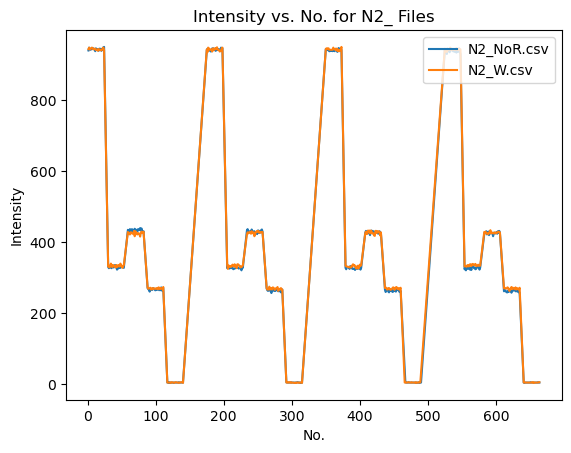

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder starting with "N2_"
csv_files = [f for f in os.listdir(folder_path) if f.startswith("N2_") and f.endswith(".csv")]

# Create a DataFrame to store data from all "N2_" files
combined_df = pd.DataFrame()

# Iterate through the "N2_" files and plot their data
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each "N2_" file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for N2_ Files")

# Show legend for each "N2_" file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


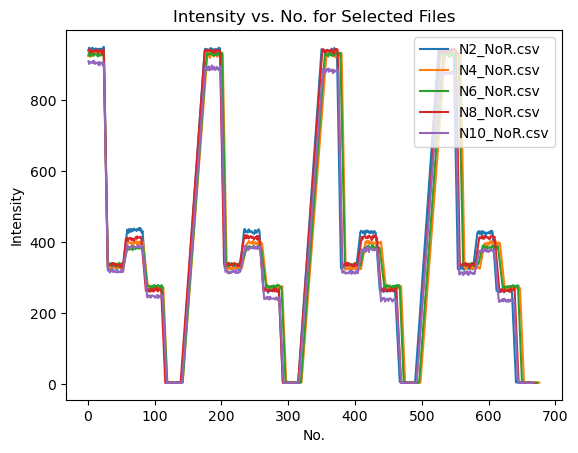

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List of file names to include in the graph
file_names = [f"N{i}_NoR.csv" for i in [2, 4, 6, 8, 10]]

#file_names = ["N2_R.csv", "N4_R.csv", "N6_R.csv", "N8_R.csv", "N10_R.csv"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for csv_file in file_names:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each selected file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


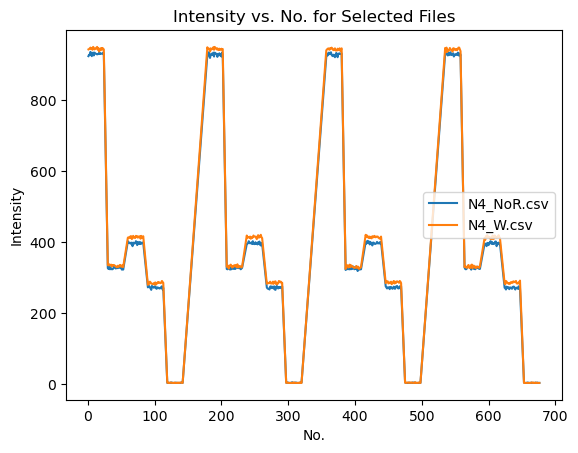

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List of file names to include in the graph
file_names = ["N4_NoR.csv", "N4_W.csv"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for csv_file in file_names:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each selected file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


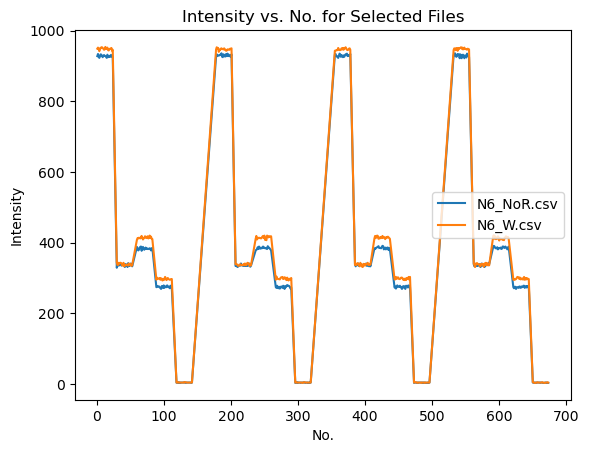

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List of file names to include in the graph
file_names = ["N6_NoR.csv", "N6_W.csv"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for csv_file in file_names:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each selected file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


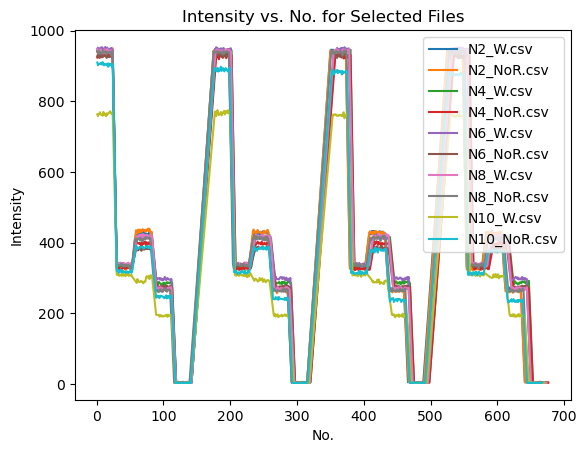

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List of N values and file name prefixes
n_values = [2, 4, 6, 8, 10]
file_name_prefixes = ["W", "NoR"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for n in n_values:
    for prefix in file_name_prefixes:
        # Construct the full file path
        csv_file = f"N{n}_{prefix}.csv"
        file_path = os.path.join(folder_path, csv_file)

        # Load the CSV file
        df = pd.read_csv(file_path)

        # Plot the data for each selected file
        plt.plot(df['No.'], df['Intensity'], label=csv_file)

        # Append the data to the combined DataFrame
        combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


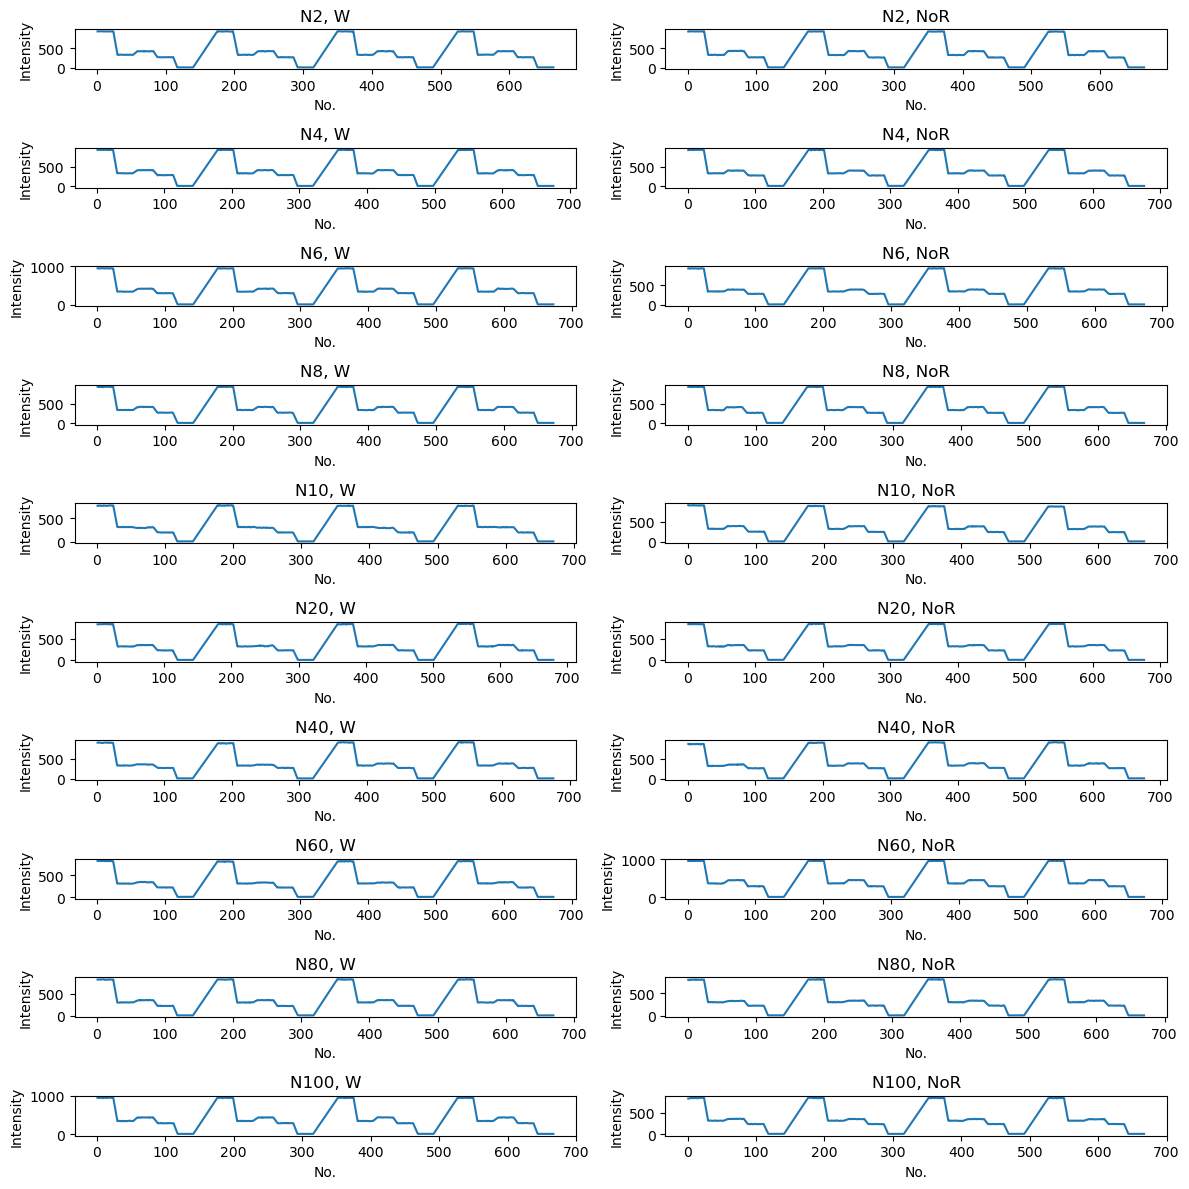

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# List of N values and file name prefixes
n_values = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100]
file_name_prefixes = ["W", "NoR"]

# Create subplots for each N value
fig, axs = plt.subplots(len(n_values), len(file_name_prefixes), figsize=(12, 12))

# Iterate through the selected files and plot their data
for i, n in enumerate(n_values):
    for j, prefix in enumerate(file_name_prefixes):
        # Construct the full file path
        csv_file = f"N{n}_{prefix}.csv"
        file_path = os.path.join(folder_path, csv_file)

        # Load the CSV file
        df = pd.read_csv(file_path)

        # Plot the data for each selected file on the respective subplot
        ax = axs[i, j]
        ax.plot(df['No.'], df['Intensity'])
        ax.set_title(f"N{n}, {prefix}")
        ax.set_xlabel("No.")
        ax.set_ylabel("Intensity")

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


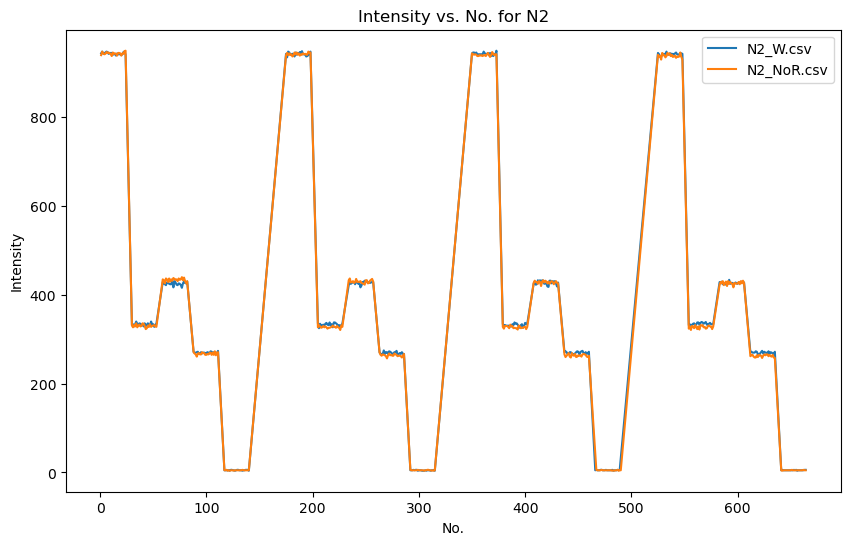

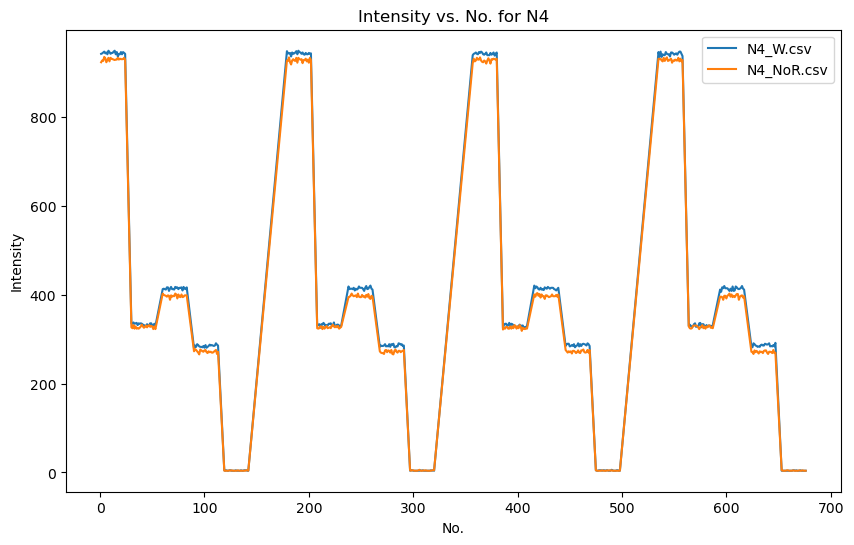

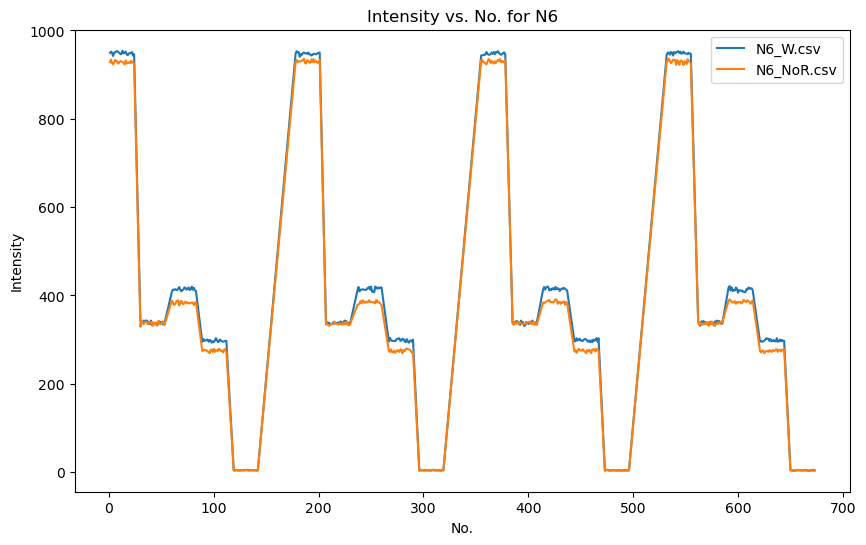

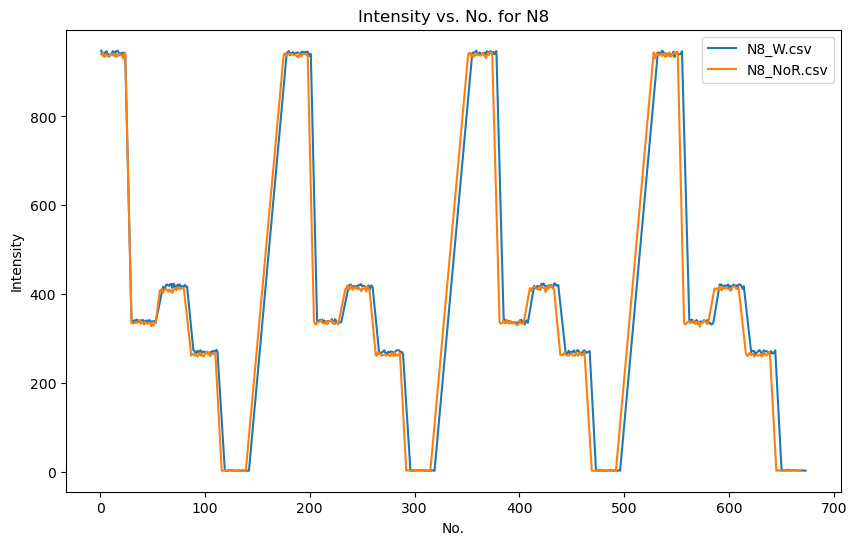

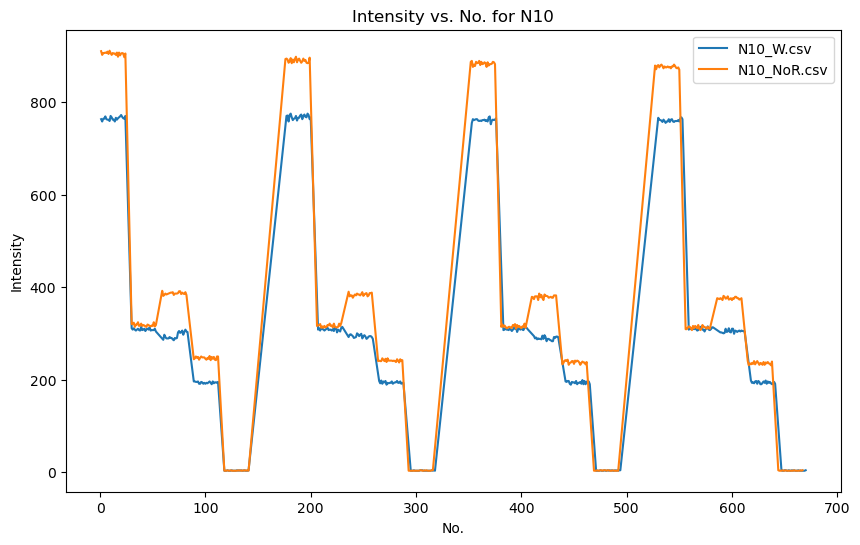

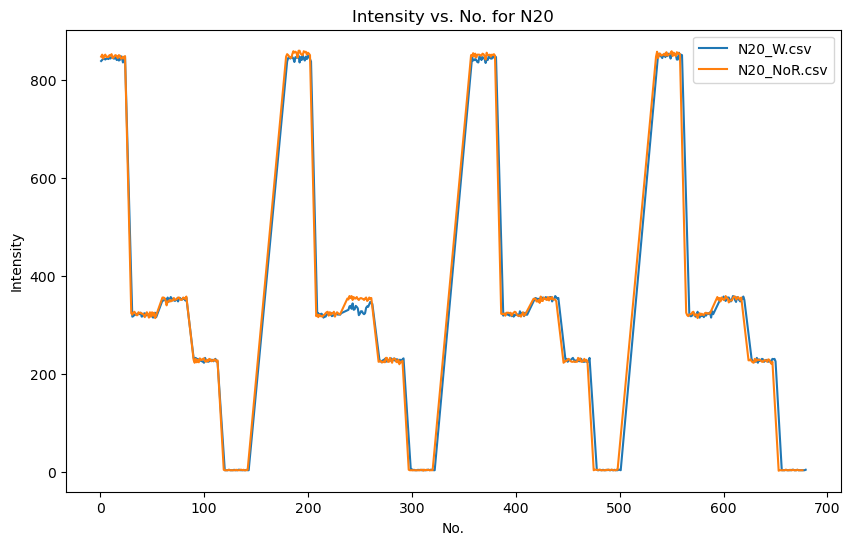

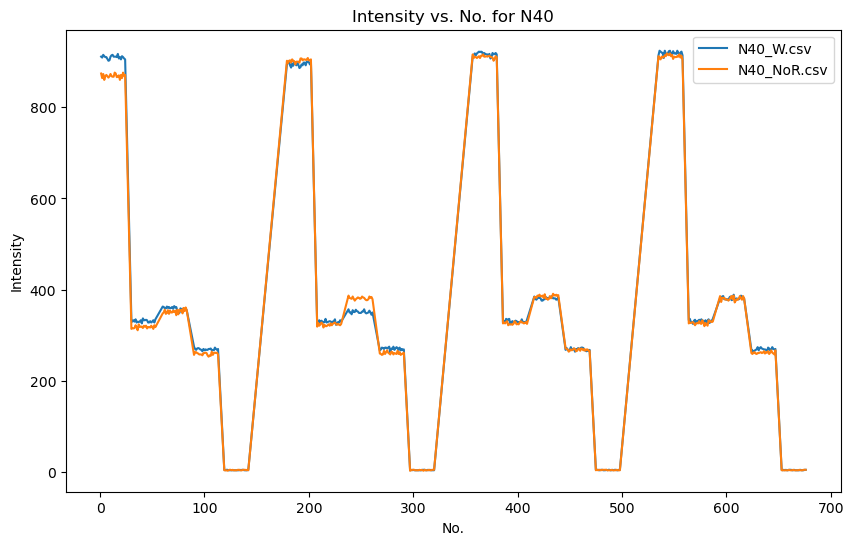

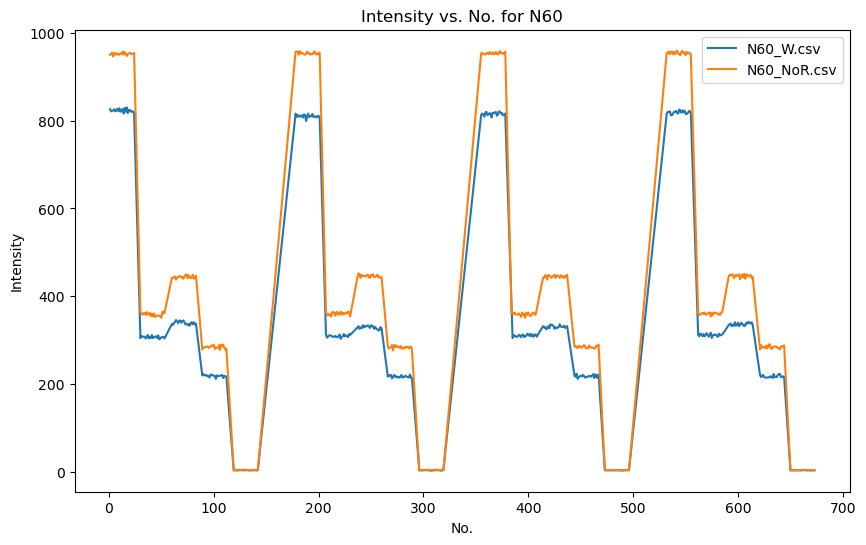

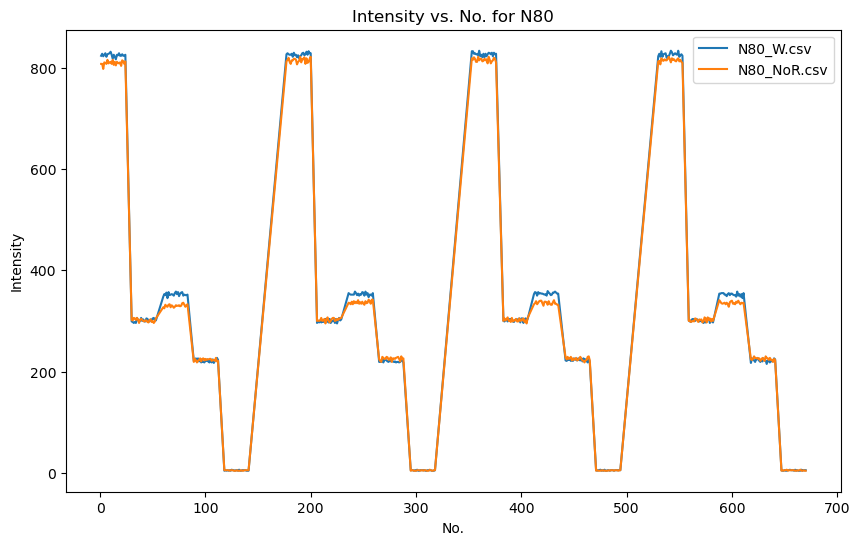

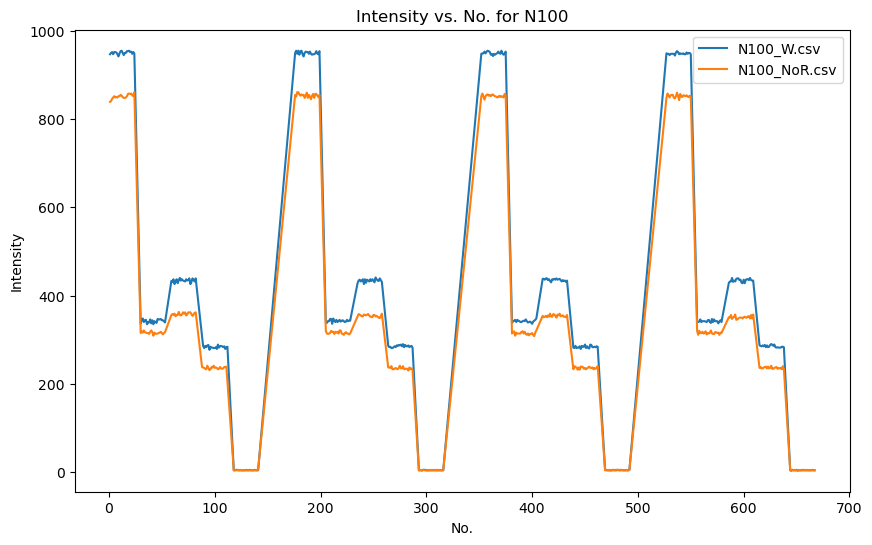

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# List of N values and file name prefixes
n_values = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100]
file_name_prefixes = ["W", "NoR"]

# Iterate through the selected files and plot their data
for n in n_values:
    plt.figure(figsize=(10, 6))  # Create a new figure for each N value

    for prefix in file_name_prefixes:
        # Construct the full file path
        csv_file = f"N{n}_{prefix}.csv"
        file_path = os.path.join(folder_path, csv_file)

        # Load the CSV file
        df = pd.read_csv(file_path)

        # Plot the data for each selected file
        plt.plot(df['No.'], df['Intensity'], label=csv_file)

        # Append the data to the combined DataFrame
        combined_df = pd.concat([combined_df, df], ignore_index=True)

    # Set labels and title for the plot
    plt.xlabel("No.")
    plt.ylabel("Intensity")
    plt.title(f"Intensity vs. No. for N{n}")

    # Show legend for each selected file
    plt.legend()

    # Show the plot for the current N value
    plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "NdatasetCSV"

# Plot the data for each group
for group_idx, csv_files_to_plot in enumerate(csv_files_to_plot_list):
    plot_group_data(csv_files_to_plot, group_idx)

# Function to plot data for a group
def plot_group_data(csv_files_to_plot, group_idx):
    # Create an empty DataFrame to store data from selected files
    combined_df = pd.concat([pd.read_csv(os.path.join(folder_path, csv_file))['Intensity'] for csv_file in csv_files_to_plot], axis=1, ignore_index=True)
    combined_df.columns = csv_files_to_plot

    # Plot the data
    plt.figure(figsize=(10, 6))
    for csv_file in csv_files_to_plot:
        plt.plot(combined_df.index, combined_df[csv_file], label=csv_file)

    plt.xlabel("No.")
    plt.ylabel("Intensity")
    plt.title(f"Intensity vs. No. (Group {group_idx + 1})")
    plt.legend()
    plt.grid(True)
    plt.show()

# List of lists containing CSV files to be plotted for each group
groups = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100]  # Define the groups
csv_files_to_plot_list = [[f"N{group}_R.csv", f"N{group}_W.csv", f"N{group}_NoR.csv", f"N{group}_WR.csv"] for group in groups]


NameError: name 'csv_files_to_plot_list' is not defined

โค๊ดคำนวณค่าเฉลี่ยและส่วนเบี่บงเบนมาตรฐานของ Intensity ของทุกไฟล์ในโฟลเดอร์ NdatasetCSV

In [1]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty lists to store the calculated statistics
average_intensity_values = []
std_dev_intensity_values = []

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Append the calculated statistics to the lists
        average_intensity_values.append(mean_intensity)
        std_dev_intensity_values.append(std_dev_intensity)
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Combine the calculated statistics from all files into one DataFrame
average_intensity_df = pd.concat(average_intensity_values, axis=1)
std_dev_intensity_df = pd.concat(std_dev_intensity_values, axis=1)

# Rename columns to indicate file names
average_intensity_df.columns = csv_files
std_dev_intensity_df.columns = csv_files

# Sort the DataFrame columns by file names
average_intensity_df = average_intensity_df.sort_index(axis=1)
std_dev_intensity_df = std_dev_intensity_df.sort_index(axis=1)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)


Average Intensity Values:
             N100_NoR.csv  N100_W.csv  N10_NoR.csv  N10_W.csv  N20_NoR.csv  \
Order Color                                                                  
1     Black          4.00        4.25         3.25       3.25         4.25   
      Blue         236.00      285.25       239.25     196.75       226.25   
      Green        353.25      432.00       381.75     293.50       354.00   
      Red          317.25      339.00       314.75     308.50       322.50   
      White        848.50      948.50       892.25     763.50       847.75   
...                   ...         ...          ...        ...          ...   
24    Black          4.50        4.25         3.50       3.75         4.50   
      Blue         236.00      283.25       242.25     192.25       226.50   
      Green        358.50      434.50       382.25     296.75       354.25   
      Red          316.75      342.50       315.50     310.00       320.25   
      White        855.75      950.75 

# บันทึกไฟล์รวมข้อมูล ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตราฐานของไฟล์ในโฟลเดอร์  NdatasetCSV  บันทึกเป็นชื่อ  N_Mean.csv  และ N_StdDeV.csv  ในโฟลเดอร์ StandardData

In [2]:
import os
import pandas as pd

# Specify the folder path
folder_path = "NdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "N_Mean.csv"
output_stddev_filename = "N_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             N2_NoR.csv  N10_NoR.csv  N20_W.csv  N2_W.csv  N60_W.csv  \
Order Color                                                            
1     Black        5.50         3.25       4.50      5.00       4.00   
      Blue       267.25       239.25     228.75    271.00     219.50   
      Green      429.50       381.75     346.50    426.25     333.00   
      Red        327.50       314.75     319.50    333.50     308.75   
      White      941.25       892.25     843.25    944.00     817.75   
...                 ...          ...        ...       ...        ...   
24    Black        5.00         3.50       4.25      5.00       4.50   
      Blue       264.75       242.25     229.25    271.25     217.25   
      Green      428.50       382.25     351.25    428.75     333.00   
      Red        328.25       315.50     320.75    334.75     309.25   
      White      942.00       888.25     845.00    945.50     813.50   

             N8_NoR.csv  N4_W.csv  N6

# ปรับแต่งหัวตาราง

In [3]:
import pandas as pd

# Function to remove ".csv" from column names and save the modified DataFrame
def remove_csv_extension_and_save(filename):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove the ".csv" from column names
    df.columns = [col.replace('.csv', '') for col in df.columns]

    # Save the modified DataFrame back to the original file
    df.to_csv(filename, index=False)

# List of files to process
file_list = ["StandardData/N_mean.csv", "StandardData/N_stddev.csv"]

# Process each file
for file in file_list:
    remove_csv_extension_and_save(file)
    print(f"Updated {file} with modified column names.")


Updated StandardData/N_mean.csv with modified column names.
Updated StandardData/N_stddev.csv with modified column names.


เปิดไฟล์ N_mean.csv เพื่อดูข้อมูล

In [4]:
import pandas as pd

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Display the DataFrame
print(df)


     Order  Color  N2_NoR  N10_NoR   N20_W    N2_W   N60_W  N8_NoR    N4_W  \
0        1  Black    5.50     3.25    4.50    5.00    4.00    3.00    4.50   
1        1   Blue  267.25   239.25  228.75  271.00  219.50  263.25  283.00   
2        1  Green  429.50   381.75  346.50  426.25  333.00  412.00  416.25   
3        1    Red  327.50   314.75  319.50  333.50  308.75  337.50  330.50   
4        1  White  941.25   892.25  843.25  944.00  817.75  939.50  944.75   
..     ...    ...     ...      ...     ...     ...     ...     ...     ...   
115     24  Black    5.00     3.50    4.25    5.00    4.50    3.25    4.00   
116     24   Blue  264.75   242.25  229.25  271.25  217.25  266.50  287.25   
117     24  Green  428.50   382.25  351.25  428.75  333.00  411.75  414.25   
118     24    Red  328.25   315.50  320.75  334.75  309.25  334.75  330.75   
119     24  White  942.00   888.25  845.00  945.50  813.50  941.25  942.75   

     N60_NoR  ...    N6_W   N10_W    N8_W  N20_NoR  N4_NoR  N80

In [5]:
import pandas as pd
import os

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_mean.csv")

# Calculate the average of the columns following the "Color" column
# Group the data by the "Color" column and calculate the mean
average_by_color = df.groupby("Color").mean()

# Display the result
print("Average by Color:")
print(average_by_color)

# Define the output file path
output_folder = "StandardData"
output_filename = "N_all_Mean.csv"
output_path = os.path.join(output_folder, output_filename)

# Check if the file "N_all_Mean.csv" already exists
if os.path.exists(output_path):
    print(f"'{output_filename}' already exists. Overwriting the file.")

# Save the DataFrame to a CSV file
average_by_color.to_csv(output_path)

print(f"Data saved to '{output_path}' as 'N_all_Mean.csv'.")


Average by Color:
       Order      N2_NoR     N10_NoR       N20_W        N2_W       N60_W  \
Color                                                                      
Black   12.5    5.010417    3.291667    4.322917    5.093750    4.135417   
Blue    12.5  264.479167  240.250000  227.968750  269.708333  218.000000   
Green   12.5  429.635417  381.260417  348.270833  426.770833  333.947917   
Red     12.5  328.125000  315.250000  320.927083  333.354167  309.635417   
White   12.5  941.364583  888.583333  844.614583  943.072917  816.677083   

           N8_NoR        N4_W     N60_NoR       N40_W  ...        N6_W  \
Color                                                  ...               
Black    3.291667    4.333333    4.291667    4.385417  ...    4.052083   
Blue   264.479167  286.239583  284.406250  269.552083  ...  297.989583   
Green  412.656250  414.562500  445.354167  368.020833  ...  414.020833   
Red    336.062500  331.937500  359.729167  330.552083  ...  338.031250   
White

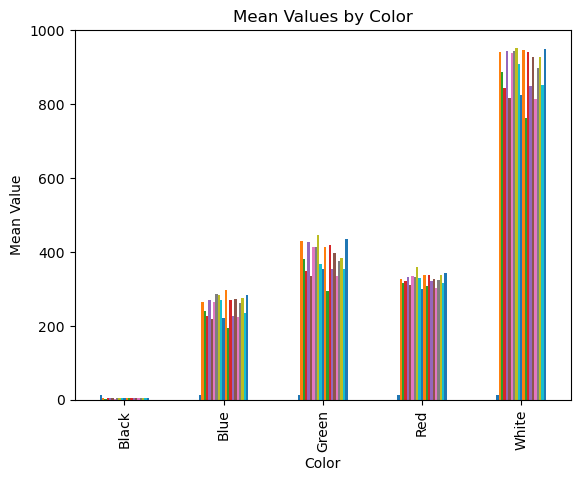

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Plot a bar chart with "Color" on the x-axis and the mean values on the y-axis
df.plot(x="Color", kind="bar", legend=None)

# Set labels and title
plt.xlabel("Color")
plt.ylabel("Mean Value")
plt.title("Mean Values by Color")

# Show the plot
plt.show()


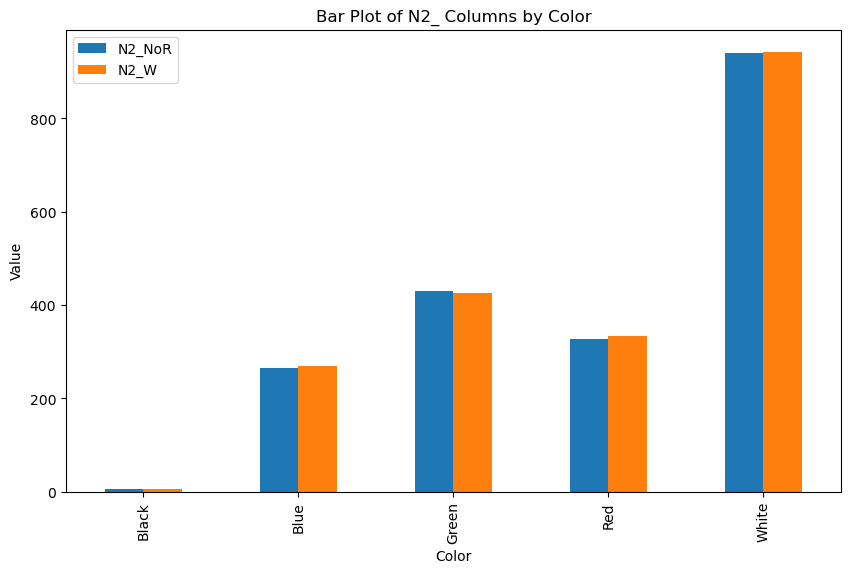

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter columns that start with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n2_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of N2_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()



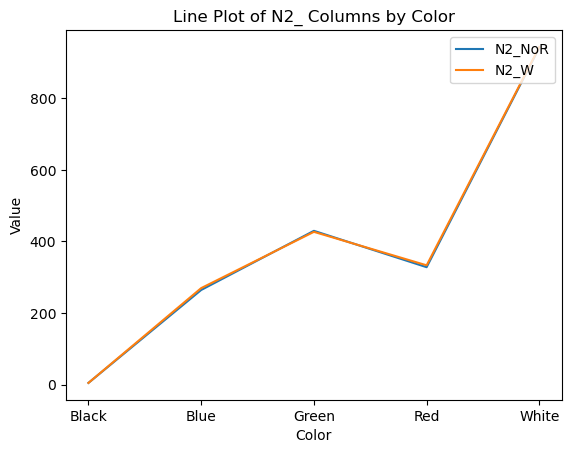

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Filter the columns starting with "N2_"
n2_columns = [col for col in df.columns if col.startswith("N2_")]

# Set "Color" column as the x-axis
x = df["Color"]

# Plot each "N2_" column as a separate line
for col in n2_columns:
    y = df[col]
    plt.plot(x, y, label=col)

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of N2_ Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


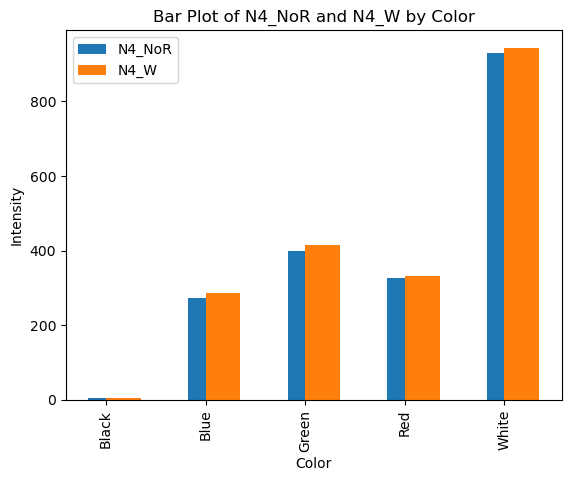

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "N4_NoR", "N4_W"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["N4_NoR"]
y2 = df["N4_W"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="N4_NoR", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="N4_W", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_NoR and N4_W by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



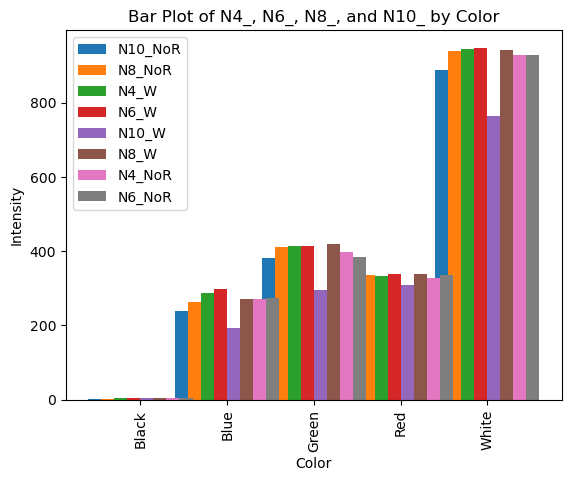

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/N_all_Mean.csv")

# Select the columns "Color," "N4_NoR," "N4_W," "N6_NoR," "N6_W," "N8_NoR," "N8_W," "N10_NoR," and "N10_W"
selected_columns = [col for col in df.columns if col.startswith("N4_") or col.startswith("N6_") or col.startswith("N8_") or col.startswith("N10_")]
df = df[["Color"] + selected_columns]

# Set "Color" column as the x-axis
x = df["Color"]

# Create a list of y-values for the selected columns
y_values = [df[col] for col in selected_columns]

# Define the width of the bars
bar_width = 0.15

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the values as side-by-side bars
for i, y in enumerate(y_values):
    plt.bar([x + i * bar_width for x in x_indexes], y, width=bar_width, label=selected_columns[i])

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of N4_, N6_, N8_, and N10_ by Color")
plt.xticks([x + bar_width * (len(selected_columns) - 1) / 2 for x in x_indexes], x, rotation=90)
plt.legend()

# Show the plot
plt.show()


In [1]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_all_Mean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ระบุคอลัมน์ที่ต้องการดึงข้อมูล

columns_to_display = ["Color"] + [col for col in data.columns if any(col.startswith(f"N{i}_") for i in [20, 40, 60, 80, 100])]

# แสดงข้อมูลที่เลือกบนหน้าจอ
selected_data = data[columns_to_display]
print(selected_data)


   Color       N20_W       N60_W     N60_NoR       N40_W       N80_W  \
0  Black    4.322917    4.135417    4.291667    4.385417    4.697917   
1   Blue  227.968750  218.000000  284.406250  269.552083  221.656250   
2  Green  348.270833  333.947917  445.354167  368.020833  353.093750   
3    Red  320.927083  309.635417  359.729167  330.552083  300.781250   
4  White  844.614583  816.677083  953.135417  909.979167  826.447917   

      N20_NoR     N80_NoR     N40_NoR    N100_NoR      N100_W  
0    4.281250    4.593750    4.333333    4.208333    4.166667  
1  227.218750  224.468750  262.562500  235.906250  284.291667  
2  352.906250  334.510417  374.697917  354.322917  434.520833  
3  322.052083  301.635417  323.770833  315.322917  342.041667  
4  850.343750  813.947917  898.291667  852.468750  949.645833  


In [2]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_all_Mean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ระบุคอลัมน์ที่ต้องการดึงข้อมูล
selected_columns = [
    "Color",
    *[f"N{i}_{j}" for i in [20, 40, 60, 80, 100] for j in ["W", "NoR"]]
]

# ดึงและเรียงลำดับข้อมูลตามคอลัมน์ "Color"
selected_data = data[selected_columns].sort_values(by="Color")

# แสดงข้อมูลที่เรียงลำดับบนหน้าจอ
print(selected_data)


   Color       N20_W     N20_NoR       N40_W     N40_NoR       N60_W  \
0  Black    4.322917    4.281250    4.385417    4.333333    4.135417   
1   Blue  227.968750  227.218750  269.552083  262.562500  218.000000   
2  Green  348.270833  352.906250  368.020833  374.697917  333.947917   
3    Red  320.927083  322.052083  330.552083  323.770833  309.635417   
4  White  844.614583  850.343750  909.979167  898.291667  816.677083   

      N60_NoR       N80_W     N80_NoR      N100_W    N100_NoR  
0    4.291667    4.697917    4.593750    4.166667    4.208333  
1  284.406250  221.656250  224.468750  284.291667  235.906250  
2  445.354167  353.093750  334.510417  434.520833  354.322917  
3  359.729167  300.781250  301.635417  342.041667  315.322917  
4  953.135417  826.447917  813.947917  949.645833  852.468750  


In [3]:
# ระบุชื่อไฟล์ CSV ที่คุณต้องการบันทึก
output_file = "StandardData/N_LMean.csv"

# บันทึกข้อมูลลงในไฟล์ CSV
selected_data.to_csv(output_file, index=False)

print("บันทึกข้อมูลลงในไฟล์", output_file)


บันทึกข้อมูลลงในไฟล์ StandardData/N_LMean.csv


In [4]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_LMean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ลบแถวที่ 0
data = data.drop(0)

# เลือกคอลัมน์ที่ต้องการคำนวณ
selected_columns = data.columns[1:]

# วนลูปเพื่อคำนวณผลต่างของแถวทุกแถว
for i in range(1, len(data)):
    row_i = data.iloc[i, 1:].values
    row_0 = data.iloc[0, 1:].values
    row_diff = row_i - row_0
    data.loc[i, selected_columns] = row_diff

# บันทึกข้อมูลที่อัปเดตแล้วลงในไฟล์ CSV ใหม่ (ไม่รวมดัชนีแถว)
output_file = "StandardData/NL_Absorpt.csv"
data.to_csv(output_file, index=False)

print("บันทึกข้อมูลลงในไฟล์", output_file)


บันทึกข้อมูลลงในไฟล์ StandardData/NL_Absorpt.csv


In [5]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# แสดงข้อมูลบนหน้าจอ
print(data)


   Color       N20_W     N20_NoR       N40_W     N40_NoR       N60_W  \
0   Blue  120.302083  125.687500   98.468750  112.135417  115.947917   
1  Green  200.625000  196.364583  232.083333  211.635417  193.687500   
2    Red  724.312500  724.656250  811.510417  786.156250  700.729167   
3  White  844.614583  850.343750  909.979167  898.291667  816.677083   

      N60_NoR       N80_W     N80_NoR      N100_W    N100_NoR  
0  160.947917  131.437500  110.041667  150.229167  118.416667  
1  198.781250  169.343750  191.593750  191.812500  196.906250  
2  792.187500  695.010417  703.906250  799.416667  734.052083  
3  953.135417  826.447917  813.947917  949.645833  852.468750  


In [6]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างรายการของคอลัมน์ที่คุณต้องการคำนวณ
columns_to_calculate = [f"N{i}_W, N{i}_NoR" for i in [20, 40, 60, 80, 100]]



# สร้าง DataFrame ที่มีเฉพาะคอลัมน์ "Color"
result = data[["Color"]]


for cols in columns_to_calculate:
    col1, col2 = cols.split(', ')
    result[f"Absorp_{col1}_{col2}"] = abs((data[col1] - data[col2]) )* 100 / data[col1]

# แสดงผลตาราง
print(result)


   Color  Absorp_N20_W_N20_NoR  Absorp_N40_W_N40_NoR  Absorp_N60_W_N60_NoR  \
0   Blue              4.476578             13.879192             38.810529   
1  Green              2.123572              8.810592              2.629881   
2    Red              0.047459              3.124318             13.051880   
3  White              0.678317              1.284370             16.708971   

   Absorp_N80_W_N80_NoR  Absorp_N100_W_N100_NoR  
0             16.278333               21.175981  
1             13.138956                2.655588  
2              1.279957                8.176535  
3              1.512497               10.232982  


/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_34843/4252479947.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[f"Absorp_{col1}_{col2}"] = abs((data[col1] - data[col2]) )* 100 / data[col1]
/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_34843/4252479947.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result[f"Absorp_{col1}_{col2}"] = abs((data[col1] - data[col2]) )* 100 / data[col1]
/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_34843/4252479947.py:20: Set

In [7]:
# ระบุชื่อไฟล์ CSV ที่คุณต้องการบันทึกผลลัพธ์
output_file = "StandardData/NL_Absorpt.csv"

# บันทึกผลลัพธ์ลงในไฟล์ CSV (ไม่รวมดัชนีแถว)
result.to_csv(output_file, index=False)

print("บันทึกผลลัพธ์ลงในไฟล์", output_file)


บันทึกผลลัพธ์ลงในไฟล์ StandardData/NL_Absorpt.csv


In [8]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)


columns_to_rename = {
    f"Absorp_N{i}_WR_N{i}_B": str(i) for i in [20, 40, 60, 80, 100]
}

# เปลี่ยนชื่อคอลัมน์ใน DataFrame
#data = data.rename(columns=columns_to_rename)

#data = data.rename(columns={"Color": "Concentrate"})


data = data.rename(columns={"Color": "Concentrate"}).transpose()

data.to_csv("StandardData/NLT_Absorpt.csv", index=False)


# บันทึกไฟล์ทับไฟล์เดิม
data.to_csv(file_path, index=False)

# แสดงผล
print(data)


                                0          1         2          3
Concentrate                  Blue      Green       Red      White
Absorp_N20_W_N20_NoR     4.476578   2.123572  0.047459   0.678317
Absorp_N40_W_N40_NoR    13.879192   8.810592  3.124318    1.28437
Absorp_N60_W_N60_NoR    38.810529   2.629881  13.05188  16.708971
Absorp_N80_W_N80_NoR    16.278333  13.138956  1.279957   1.512497
Absorp_N100_W_N100_NoR  21.175981   2.655588  8.176535  10.232982


In [9]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างคอลัมน์ "Concentrate" และใส่ข้อมูล
data.insert(0, "Concentrate", [0, 20, 40, 60, 80, 100])

# เปลี่ยนชื่อคอลัมน์
data = data.rename(columns={0: "Blue", 1: "Green", 2: "Red", 3: "White"})

# ลบข้อมูลในแถว 0
data = data.drop(0)

# บันทึกข้อมูลลงในไฟล์ CSV
data.to_csv(file_path, index=False)

# แสดงผลลัพธ์บนหน้าจอ
print(data)


   Concentrate                   0                   1                   2  \
1           20   4.476578058706398   2.123572170301166  0.0474587971352144   
2           40   13.87919179096585   8.810592459605024  3.1243180797124657   
3           60   38.81052915281645  2.6298806066473057  13.051880481641136   
4           80   16.27833254081469  13.138955526849973  1.2799568351793345   
5          100  21.175981139925085   2.655588139459061   8.176534973418136   

                    3  
1   0.678317279824373  
2  1.2843700634172028  
3   16.70897054884503  
4  1.5124970065163414  
5  10.232981594015316  


In [10]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# เปลี่ยนชื่อคอลัมน์
data = data.rename(columns={"0": "Blue"})
data = data.rename(columns={"1": "Green"})
data = data.rename(columns={"2": "Red"})
data = data.rename(columns={"3": "White"})

# บันทึกข้อมูลลงในไฟล์ CSV
data.to_csv(file_path, index=False)


In [11]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# แสดงข้อมูลบนหน้าจอ
print(data)


   Concentrate       Blue      Green        Red      White
0           20   4.476578   2.123572   0.047459   0.678317
1           40  13.879192   8.810592   3.124318   1.284370
2           60  38.810529   2.629881  13.051880  16.708971
3           80  16.278333  13.138956   1.279957   1.512497
4          100  21.175981   2.655588   8.176535  10.232982


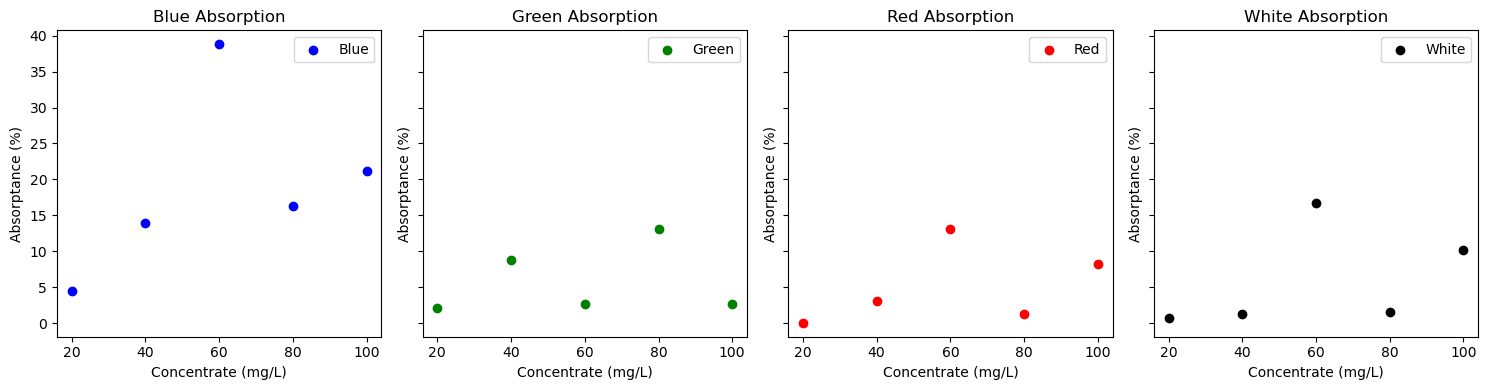

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟย่อยแยกตามคอลัมน์ Blue, Green, Red, White
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 4), sharey=True)
colors = ['b', 'g', 'r', 'black']  # สีของ Blue, Green, Red, White

# สร้างกราฟย่อยแยกตามคอลัมน์ Blue, Green, Red, White
for i, column in enumerate(["Blue", "Green", "Red", "White"]):
    ax = axes[i]
    ax.scatter(data["Concentrate"], data[column], c=colors[i], label=column)
    ax.set_xlabel("Concentrate (mg/L)")
    ax.set_ylabel("Absorptance (%)")
    ax.set_title(f"{column} Absorption")
    ax.legend()

plt.tight_layout()
plt.show()


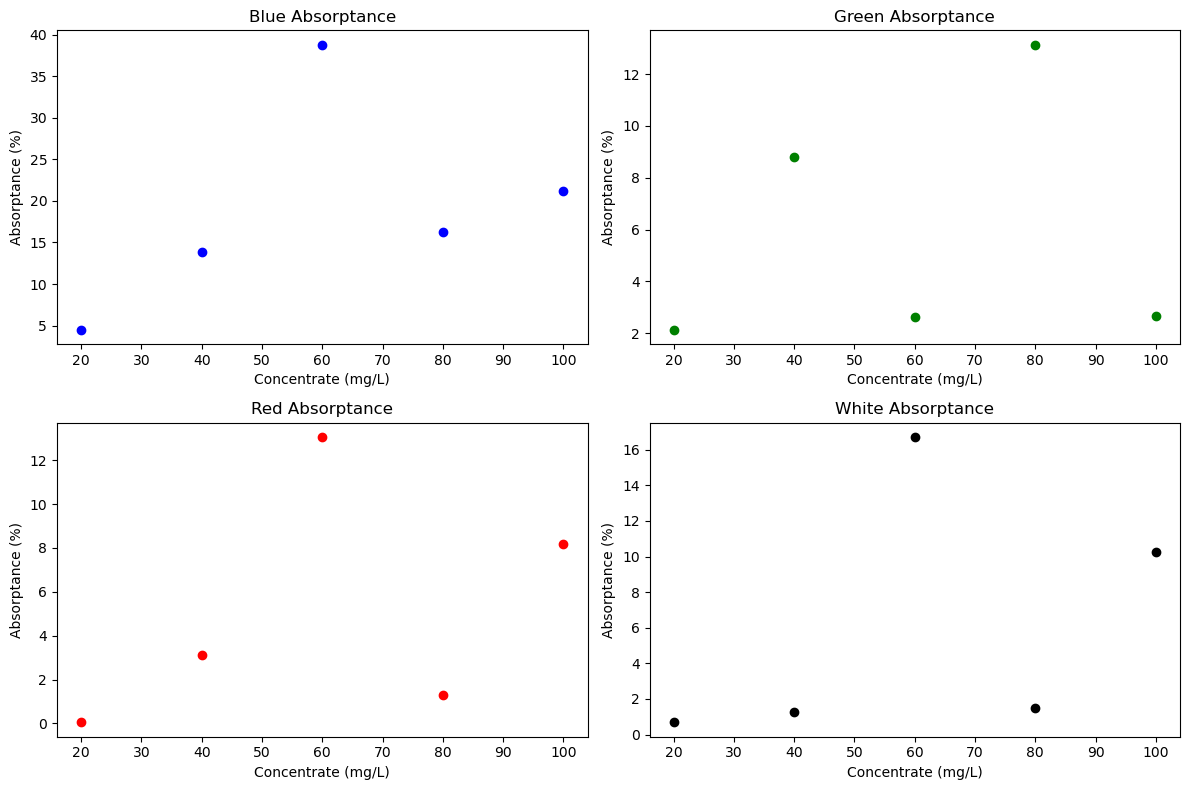

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
axs[0, 0].scatter(data['Concentrate'], data['Blue'], color='blue')
axs[0, 0].set_title('Blue Absorptance')
axs[0, 0].set_xlabel('Concentrate (mg/L)')
axs[0, 0].set_ylabel('Absorptance (%)')

# สร้างกราฟ Green
axs[0, 1].scatter(data['Concentrate'], data['Green'], color='green')
axs[0, 1].set_title('Green Absorptance')
axs[0, 1].set_xlabel('Concentrate (mg/L)')
axs[0, 1].set_ylabel('Absorptance (%)')

# สร้างกราฟ Red
axs[1, 0].scatter(data['Concentrate'], data['Red'], color='red')
axs[1, 0].set_title('Red Absorptance')
axs[1, 0].set_xlabel('Concentrate (mg/L)')
axs[1, 0].set_ylabel('Absorptance (%)')

# สร้างกราฟ White
axs[1, 1].scatter(data['Concentrate'], data['White'], color='black')
axs[1, 1].set_title('White Absorptance')
axs[1, 1].set_xlabel('Concentrate (mg/L)')
axs[1, 1].set_ylabel('Absorptance (%)')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


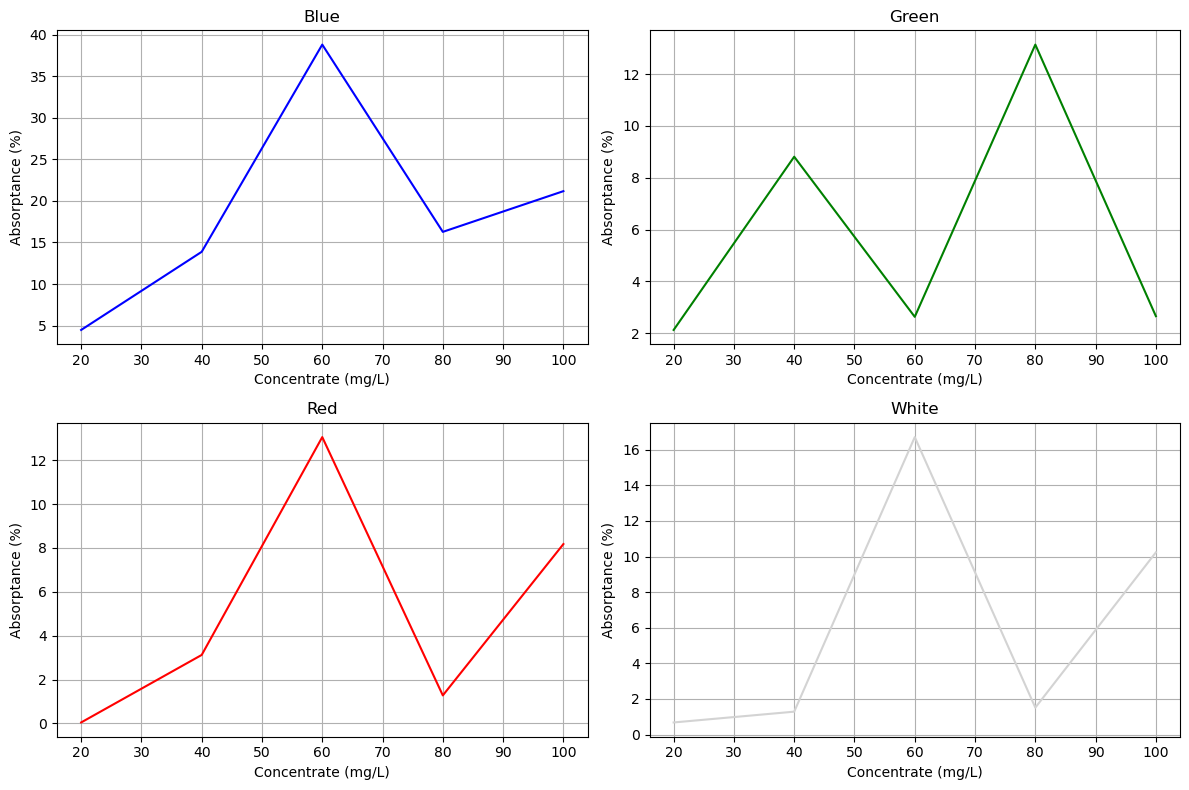

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟย่อย
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# กำหนดสี
colors = ['blue', 'green', 'red', 'lightgrey']

# ลูปเพื่อสร้างกราฟ
for i, column in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    color = colors[i]

    # สร้างกราฟ
    ax.plot(data['Concentrate'], data[column], color=color)
    ax.set_title(f'{column}')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)

# ปรับแต่งรูปแบบการแสดงผล
plt.tight_layout()

# แสดงกราฟ
plt.show()


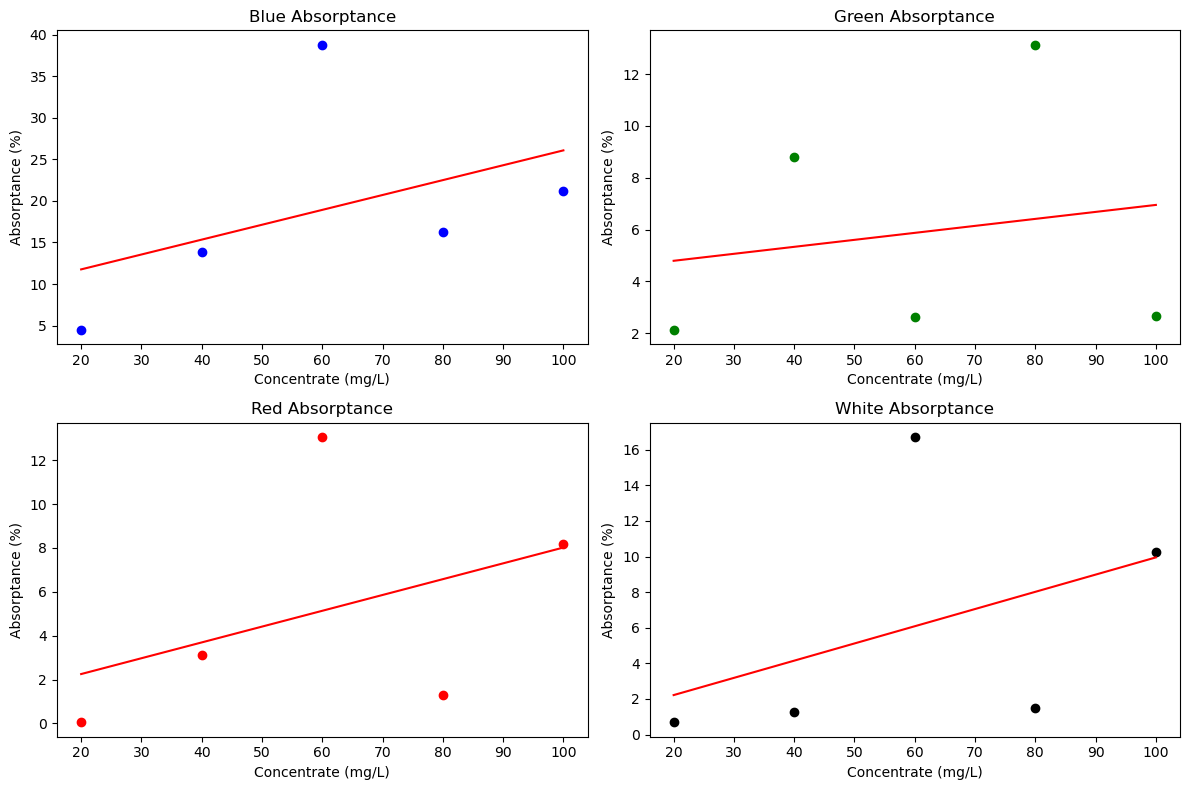

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
x = data['Concentrate']
y = data['Blue']
ax = axs[0, 0]
ax.scatter(x, y, color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ Green
x = data['Concentrate']
y = data['Green']
ax = axs[0, 1]
ax.scatter(x, y, color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ Red
x = data['Concentrate']
y = data['Red']
ax = axs[1, 0]
ax.scatter(x, y, color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ White
x = data['Concentrate']
y = data['White']
ax = axs[1, 1]
ax.scatter(x, y, color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


สมการกราฟ Blue:  
0.179 x + 8.185
R-squared ของกราฟ Blue: 0.19969563007267288


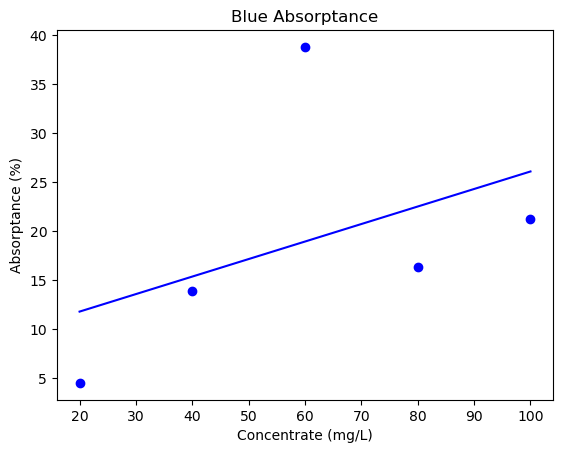

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ Blue
x_blue = data['Concentrate']
y_blue = data['Blue']
plt.scatter(x_blue, y_blue, color='blue')
plt.title('Blue Absorptance')
plt.xlabel('Concentrate (mg/L)')
plt.ylabel('Absorptance (%)')

# ทำการปรับเพื่อให้เหมาะสมกับสมการเส้นตรง
coefficients_blue = np.polyfit(x_blue, y_blue, 1)
poly_eqn_blue = np.poly1d(coefficients_blue)

# แสดงสมการ
print(f"สมการกราฟ Blue: {poly_eqn_blue}")

# คำนวณค่า R-squared
y_pred_blue = poly_eqn_blue(x_blue)
r_squared_blue = 1 - (np.sum((y_blue - y_pred_blue)**2) / np.sum((y_blue - np.mean(y_blue))**2))
print(f"R-squared ของกราฟ Blue: {r_squared_blue}")

# แสดงกราฟ
plt.plot(x_blue, poly_eqn_blue(x_blue), color='blue')
plt.show()


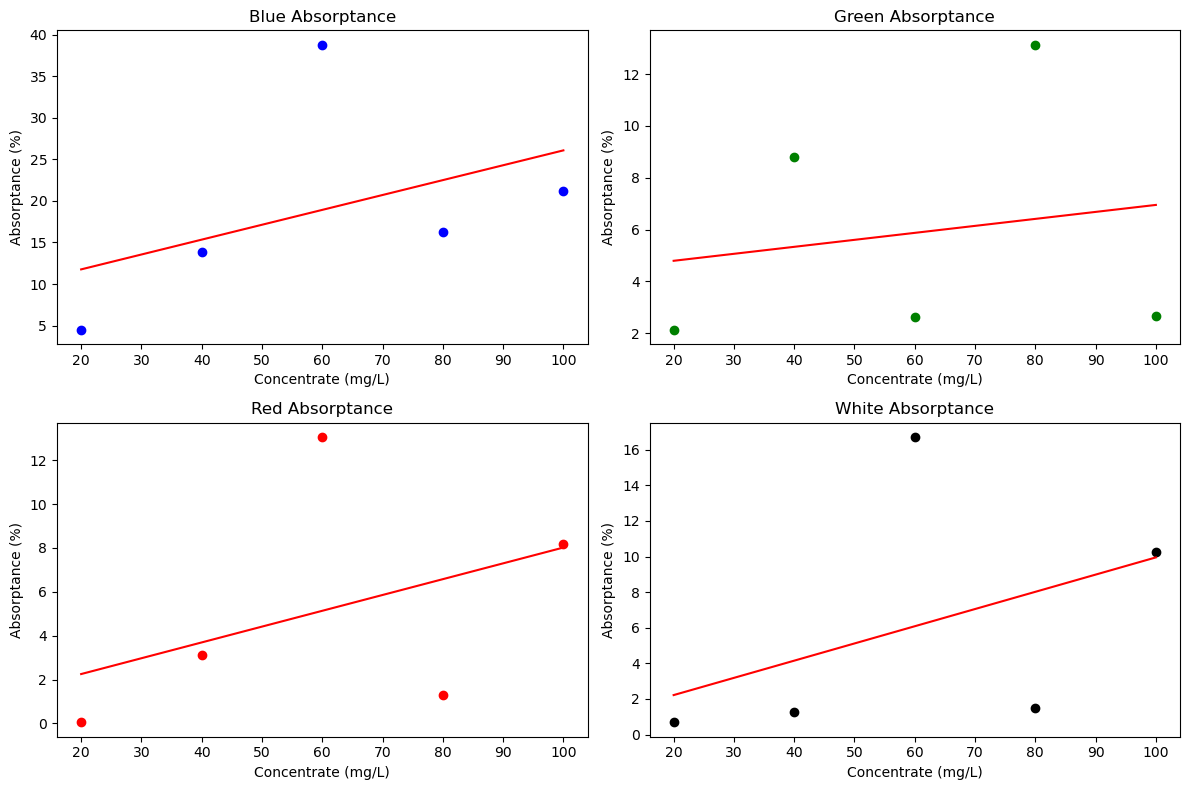

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
ax = axs[0, 0]
ax.scatter(data['Concentrate'], data['Blue'], color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Blue
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Blue'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ Green
ax = axs[0, 1]
ax.scatter(data['Concentrate'], data['Green'], color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Green
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Green'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ Red
ax = axs[1, 0]
ax.scatter(data['Concentrate'], data['Red'], color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Red
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Red'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ White
ax = axs[1, 1]
ax.scatter(data['Concentrate'], data['White'], color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น White
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['White'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


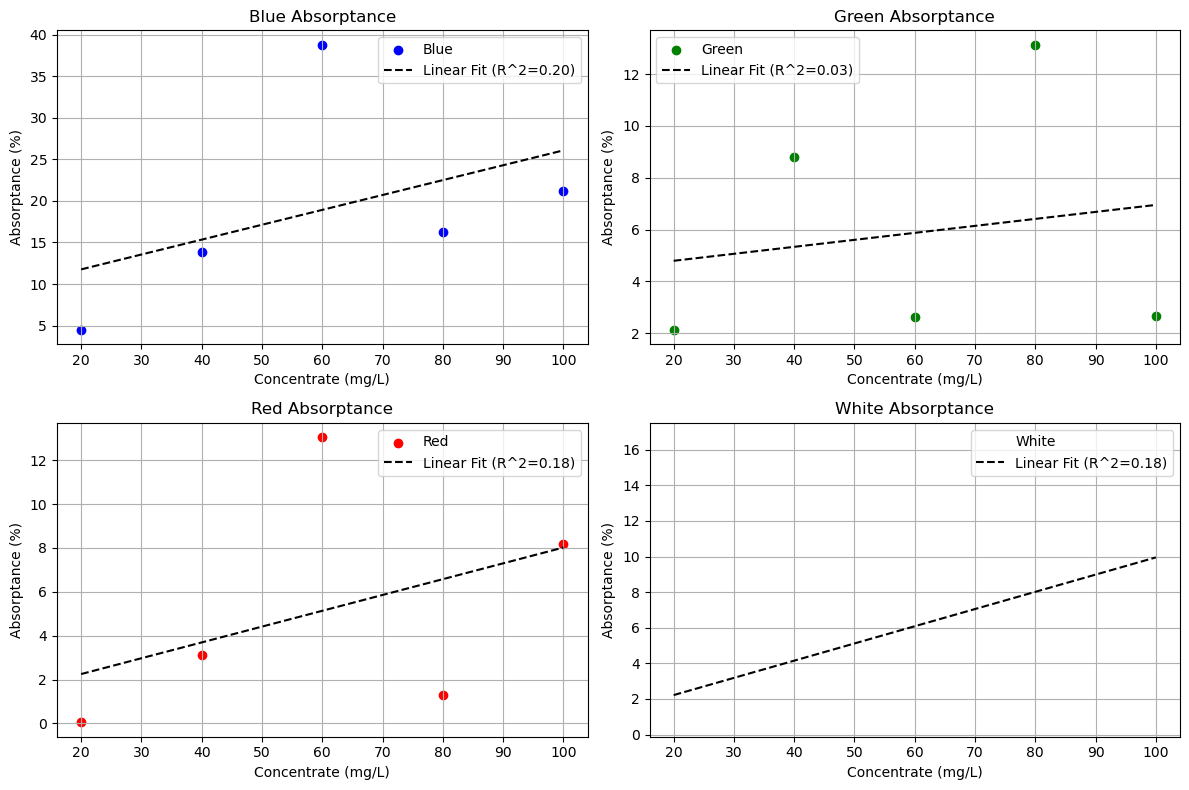

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟย่อยและคำนวณสมการเชิงเส้น และ R-squared สำหรับแต่ละกราฟย่อย
for i, color in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    x = data['Concentrate'].values.reshape(-1, 1)
    y = data[color].values

    # สร้างแบบจำลองเชิงเส้น
    model = LinearRegression()
    model.fit(x, y)
    
    # ทำนายค่า
    y_pred = model.predict(x)
    
    # คำนวณค่า R-squared
    r2 = r2_score(y, y_pred)
    
    # แสดงกราฟ
    ax.scatter(x, y, color=color, label=f'{color}')
    ax.plot(x, y_pred, color='black', linestyle='--', label=f'Linear Fit (R^2={r2:.2f})')
    ax.set_title(f'{color} Absorptance')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)
    ax.legend()

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


/var/folders/x0/v1wddh8s0c32rk82mvdl7hf40000gn/T/ipykernel_34843/2929954754.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


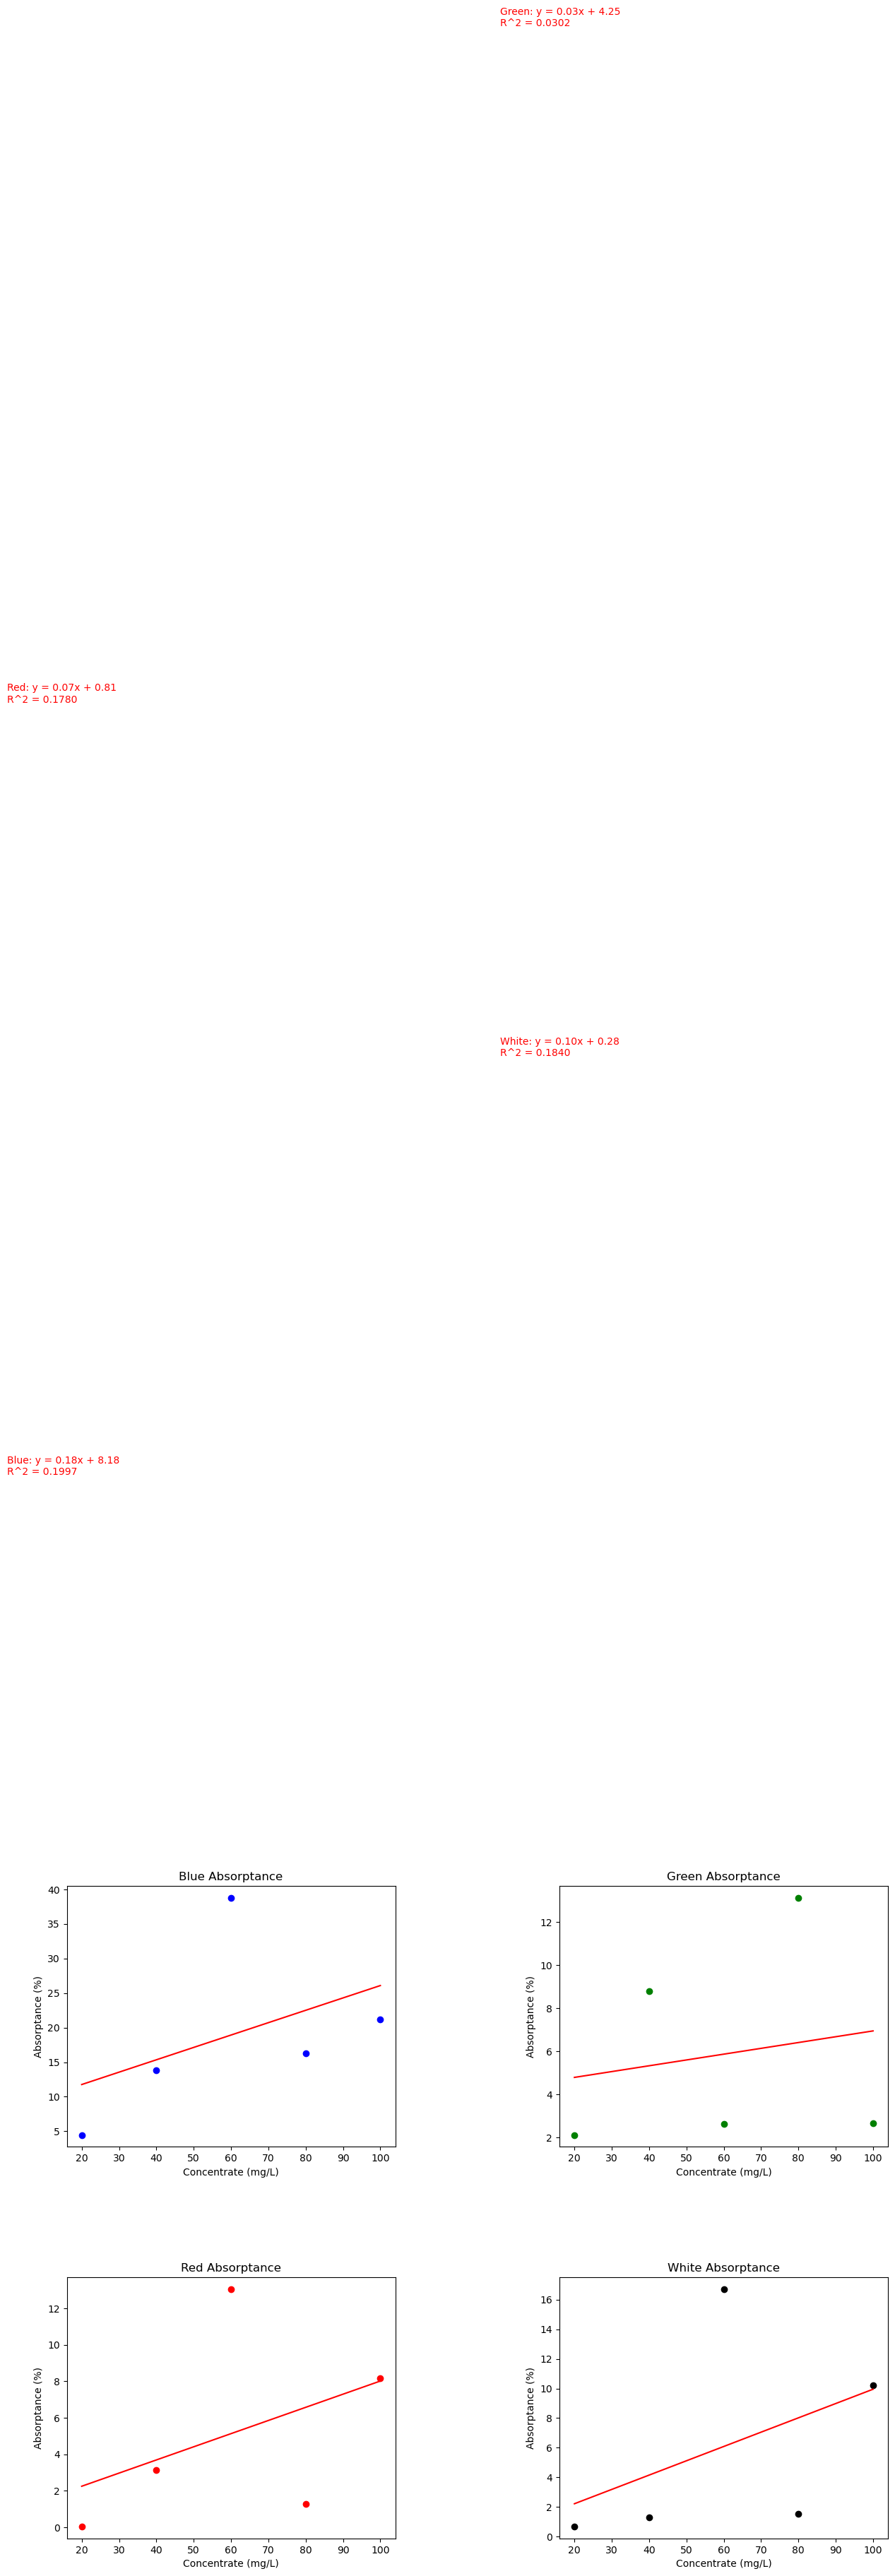

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# สร้างกราฟ Blue
ax = axs[0, 0]
ax.scatter(data['Concentrate'], data['Blue'], color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
regressor = LinearRegression()
X = data[['Concentrate']]
y = data['Blue']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0,100, f'Blue: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')



# สร้างกราฟ Green
ax = axs[0, 1]
ax.scatter(data['Concentrate'], data['Green'], color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['Green']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0, 100, f'Green: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')

# สร้างกราฟ Red
ax = axs[1, 0]
ax.scatter(data['Concentrate'], data['Red'], color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['Red']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0, 100, f'Red: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')

# สร้างกราฟ White
ax = axs[1, 1]
ax.scatter(data['Concentrate'], data['White'], color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['White']
regressor.fit(X, y)


# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0,100, f'White: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')



# ปรับระยะห่างของกราฟ
plt.tight_layout()

# ปรับระยะห่างของกราฟ
plt.subplots_adjust(wspace=.5, hspace=.5)



# แสดงกราฟ
plt.show()


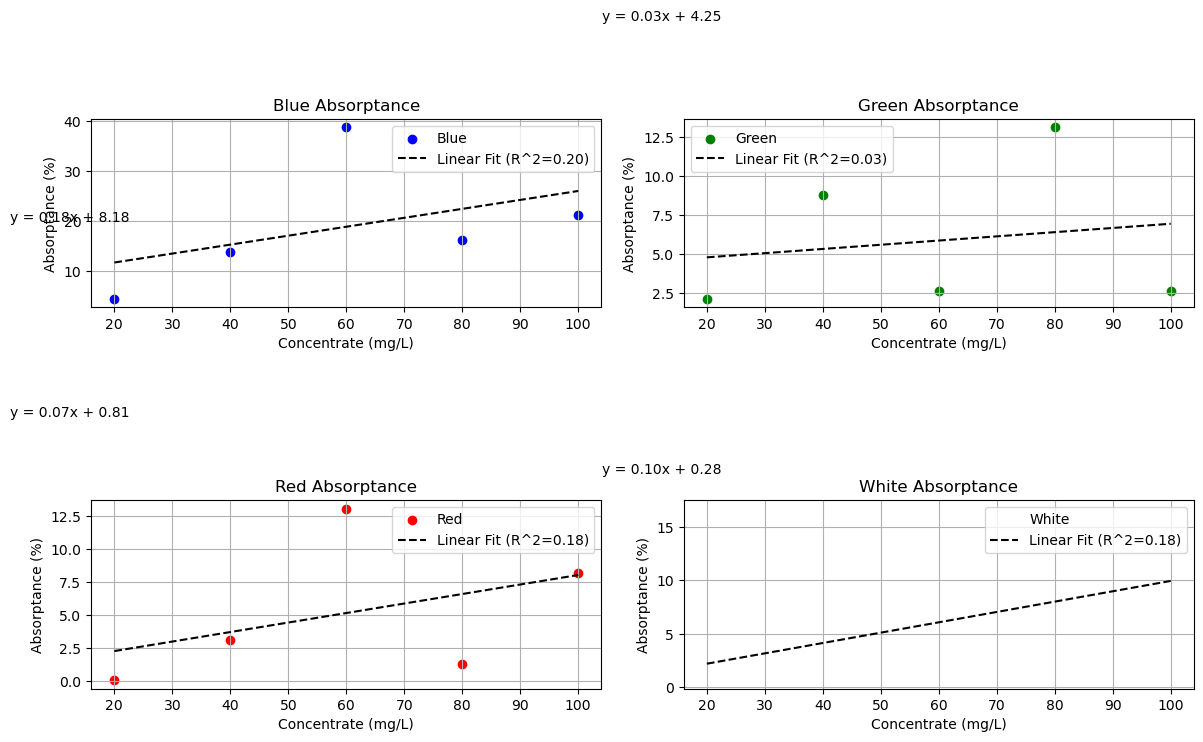

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟย่อยและคำนวณสมการเชิงเส้น และ R-squared สำหรับแต่ละกราฟย่อย
for i, color in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    x = data['Concentrate'].values.reshape(-1, 1)
    y = data[color].values

    # สร้างแบบจำลองเชิงเส้น
    model = LinearRegression()
    model.fit(x, y)
    
    # ทำนายค่า
    y_pred = model.predict(x)
    
    # คำนวณค่า R-squared
    r2 = r2_score(y, y_pred)
    
    # แสดงกราฟ
    ax.scatter(x, y, color=color, label=f'{color}')
    ax.plot(x, y_pred, color='black', linestyle='--', label=f'Linear Fit (R^2={r2:.2f})')
    ax.set_title(f'{color} Absorptance')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)
    ax.legend()
    
    # แสดงสมการเชิงเส้น
    ax.text(2,20, f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}', color='black')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()
